In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from abc import ABC, abstractmethod
import numpy as np
from sklearn.metrics import classification_report, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVR, SVC
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.utils import resample
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Wholesale customers data.csv')

X = df.values

print(f"Признаков: {X.shape[1]}, Объектов: {X.shape[0]}")

scaler = StandardScaler()
X = scaler.fit_transform(X)

Признаков: 8, Объектов: 440


In [3]:
clustering = DBSCAN(eps=2, min_samples=3).fit(X)
dbscan_labels = clustering.labels_

n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 2
Estimated number of noise points: 15


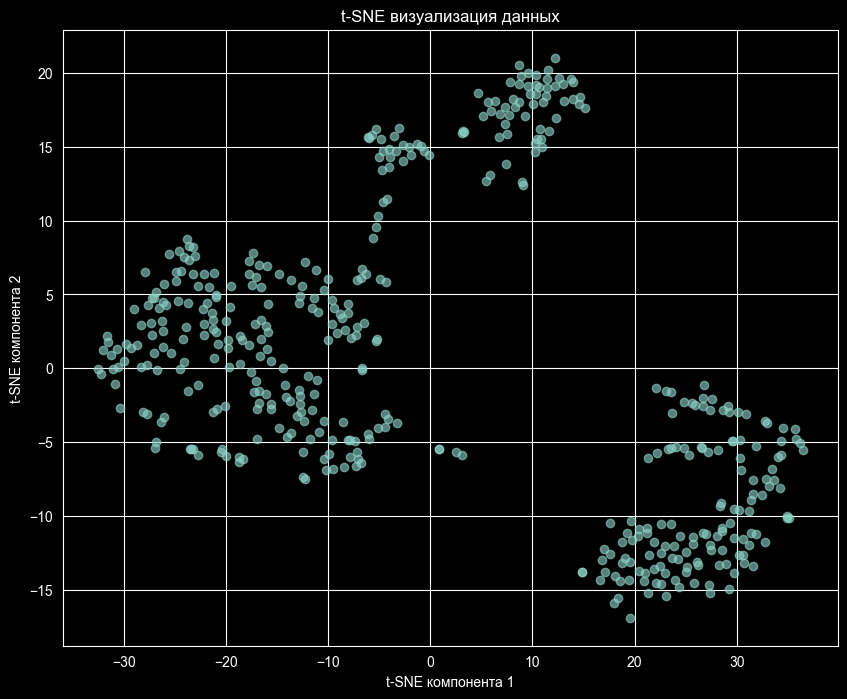

In [4]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6)
plt.title('t-SNE визуализация данных')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.grid(True)
plt.show()

In [5]:
unique, counts = np.unique(dbscan_labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c}")

Cluster -1: 15
Cluster 0: 133
Cluster 1: 292


C:\Users\User\AppData\Local\Temp\ipykernel_16772\3325119903.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


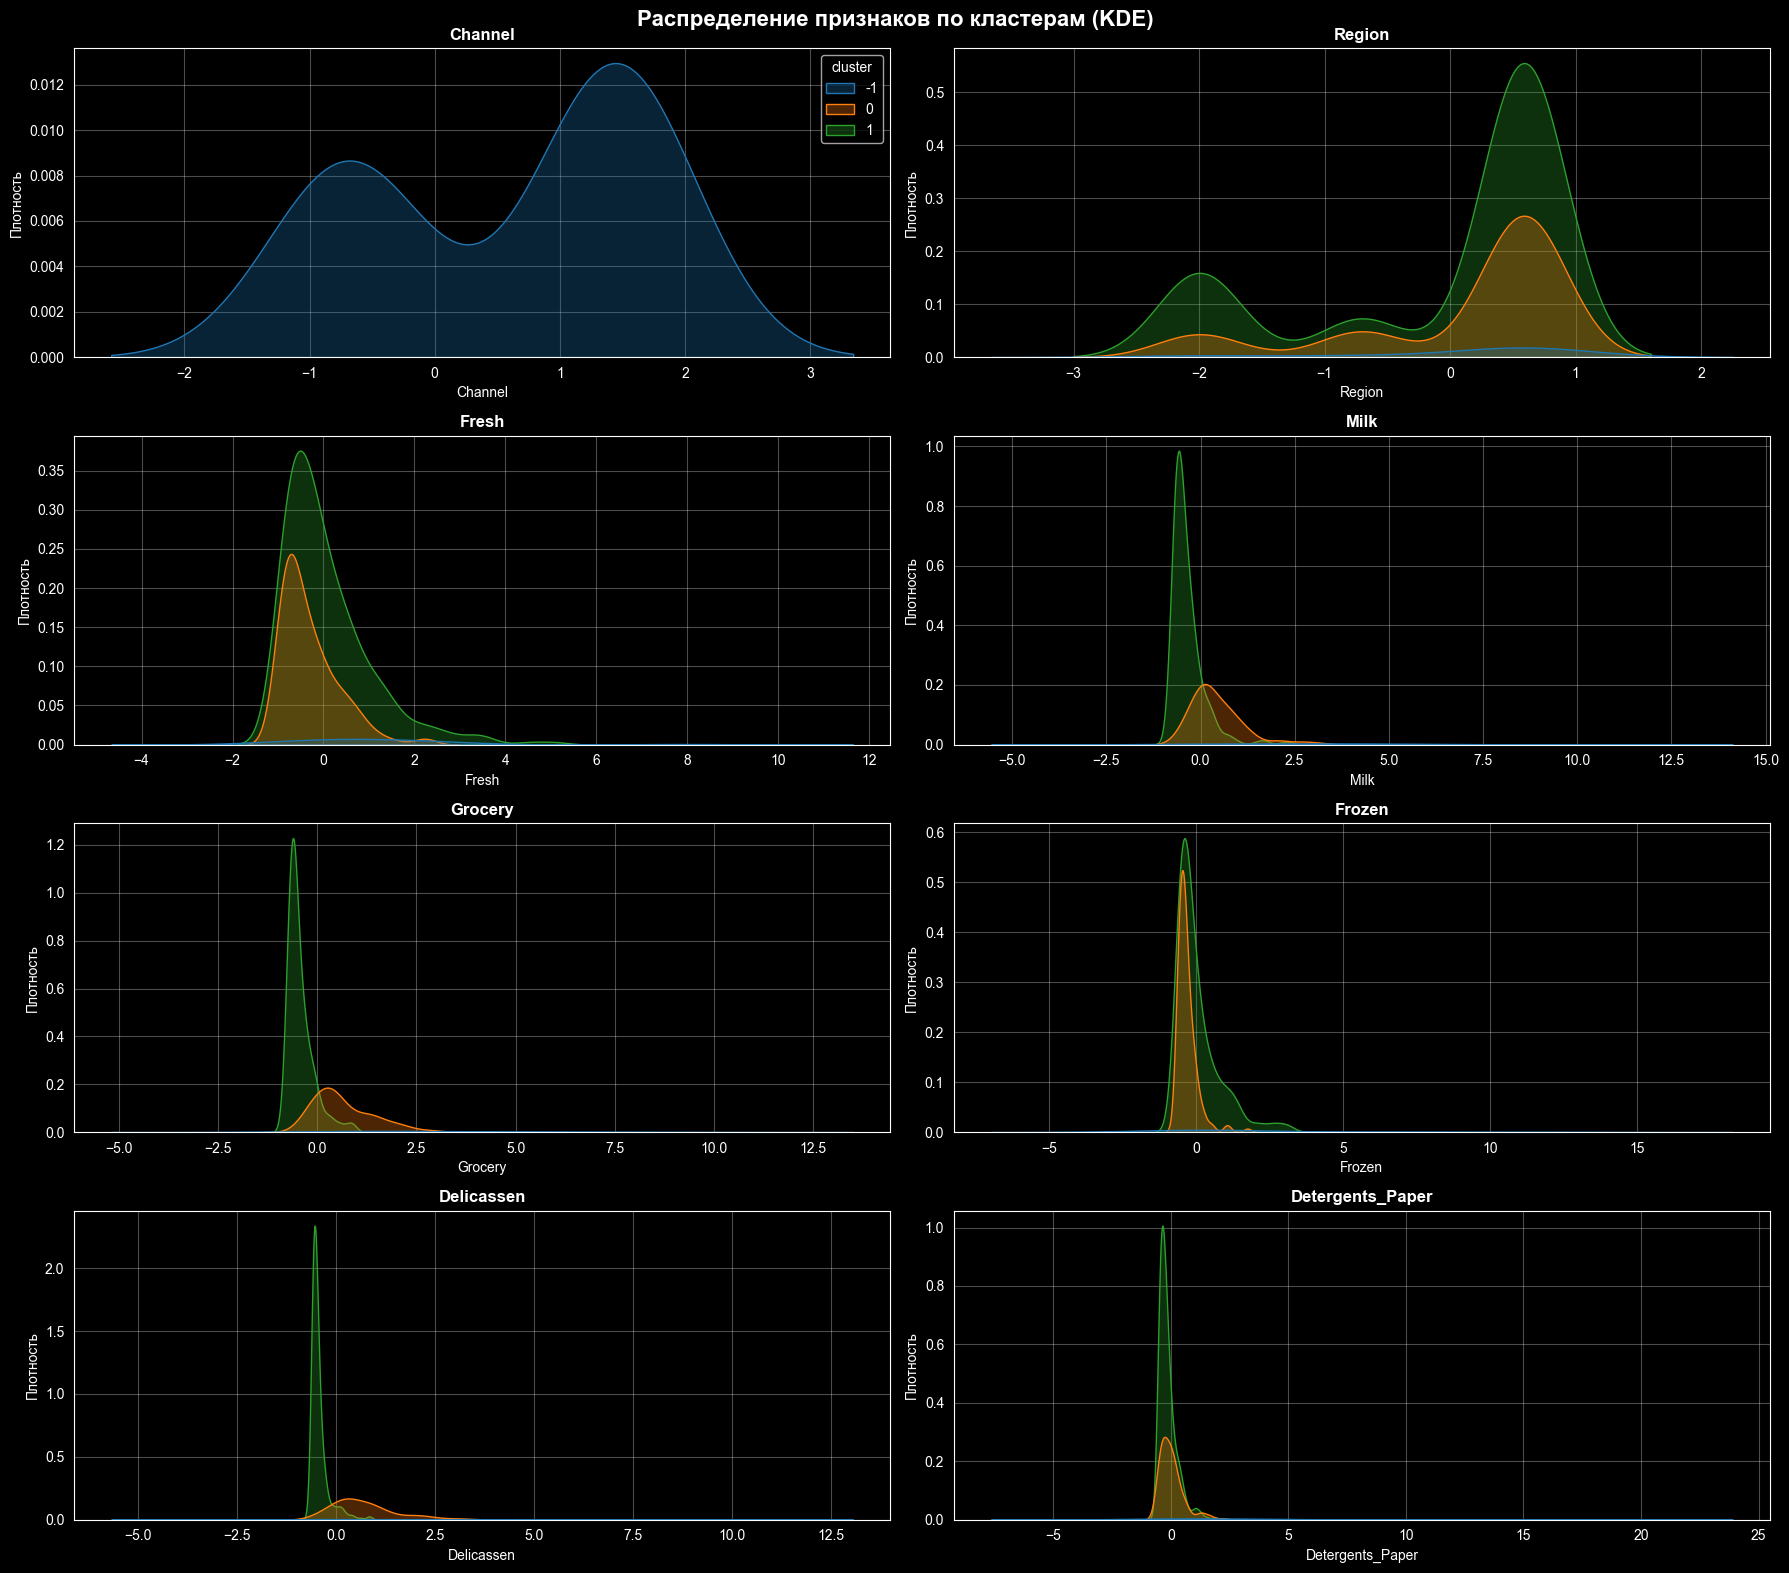

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Channel', 'Region', 'Fresh', 'Milk',
            'Grocery', 'Frozen', 'Delicassen', 'Detergents_Paper']

X_df = pd.DataFrame(X, columns=features)
X_df['cluster'] = dbscan_labels

fig, axes = plt.subplots(4, 2, figsize=(18, 16))

for i, feature in enumerate(features):
    row = i // 2
    col = i % 2

    sns.kdeplot(
        data=X_df,
        x=feature,
        hue='cluster',
        fill=True,
        alpha=0.3,
        ax=axes[row, col],
        palette='tab10'
    )
    axes[row, col].set_title(feature, fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel(feature, fontsize=10)
    axes[row, col].set_ylabel('Плотность', fontsize=10)
    axes[row, col].grid(True, alpha=0.3)

    if i != 0:
        axes[row, col].legend_.remove()

plt.suptitle('Распределение признаков по кластерам (KDE)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()